<a href="https://colab.research.google.com/github/ERAEstudianteUB2026/UBPhD-Machine-Learning2026/blob/main/CART_Clasificacion_Adult_Income.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Árbol de clasificación CART — Adult Income

Objetivo: predecir si el ingreso anual de una persona es `<=50K` o `>50K`.

##  **Nombre y Apellidos:**   **Emiliano Rodríguez**

## 1. Cargar librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Cargar datos

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columnas = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week",
    "native_country", "income"
]

df = pd.read_csv(url, names=columnas, sep=",", skipinitialspace=True, na_values="?")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 3. Exploración inicial

In [3]:
print("Dimensiones:", df.shape)
display(df.head())
df.info()

Dimensiones: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


### Variable respuesta
La variable respuesta es `income`, con dos clases: `<=50K` y `>50K`.

## 4. Valores faltantes

In [4]:
print(df.isnull().sum())

faltantes = pd.DataFrame({
    "Cantidad": df.isnull().sum(),
    "Porcentaje": df.isnull().mean() * 100
})
faltantes

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64


,Cantidad,Porcentaje
age,0,0.000000
workclass,1836,5.638647
fnlwgt,0,0.000000
education,0,0.000000
education_num,0,0.000000
marital_status,0,0.000000
occupation,1843,5.660146
relationship,0,0.000000
race,0,0.000000
sex,0,0.000000


## 5. Datos duplicados

In [5]:
print("Duplicados:", df.duplicated().sum())
print("Dimensión antes:", df.shape)

df = df.drop_duplicates().reset_index(drop=True)

print("Dimensión después:", df.shape)
print("Duplicados restantes:", df.duplicated().sum())

Duplicados: 24
Dimensión antes: (32561, 15)
Dimensión después: (32537, 15)
Duplicados restantes: 0


## 6. Variables cuantitativas y cualitativas

In [6]:
variables_num = df.select_dtypes(include=np.number).columns.tolist()
variables_cat = df.select_dtypes(exclude=np.number).columns.tolist()

print("Cuantitativas:", variables_num)
print("Cualitativas:", variables_cat)

variables_cat.remove("income")

Cuantitativas: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Cualitativas: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


## 7. Estadísticas descriptivas

In [7]:
def Descriptivas(df):
    datos = df.select_dtypes(include=np.number)
    resultados = []

    for variable in datos.columns:
        resultados.append([
            variable,
            datos[variable].mean(),
            datos[variable].median(),
            datos[variable].std(),
            datos[variable].min(),
            datos[variable].max()
        ])

    return pd.DataFrame(
        resultados,
        columns=["Variable", "Media", "Mediana", "Desviación estándar", "Mínimo", "Máximo"]
    ).round(2)

Descriptivas(df)

,Variable,Media,Mediana,Desviación estándar,Mínimo,Máximo
0,age,38.59,37.0,13.64,17,90
1,fnlwgt,189780.85,178356.0,105556.47,12285,1484705
2,education_num,10.08,10.0,2.57,1,16
3,capital_gain,1078.44,0.0,7387.96,0,99999
4,capital_loss,87.37,0.0,403.10,0,4356
5,hours_per_week,40.44,40.0,12.35,1,99


## 8. Histogramas

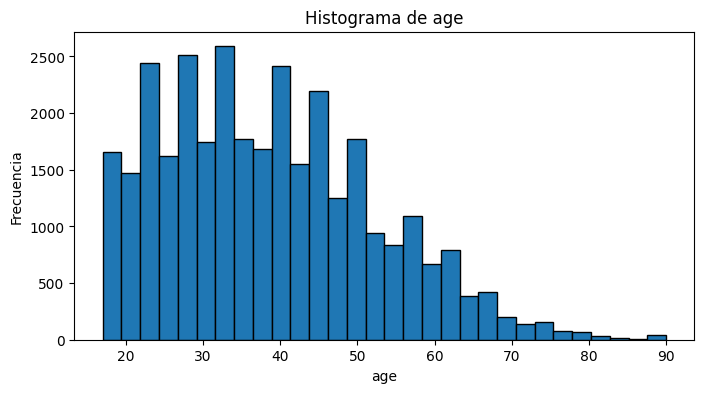

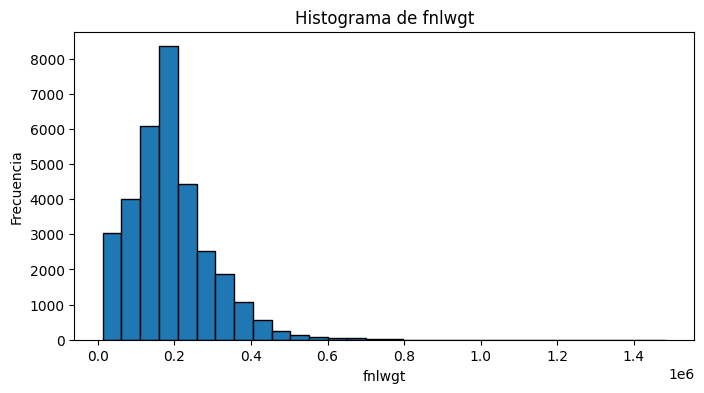

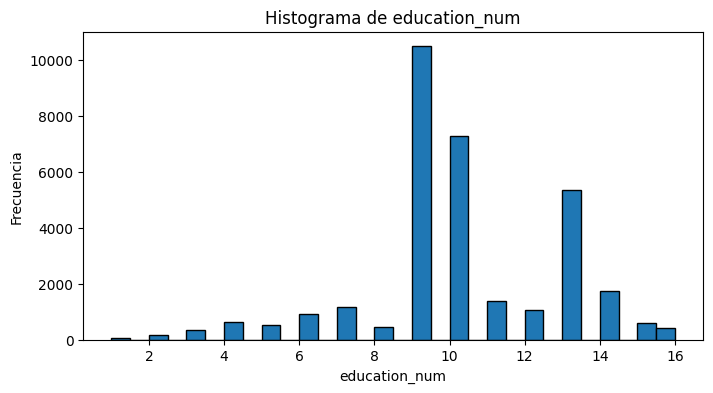

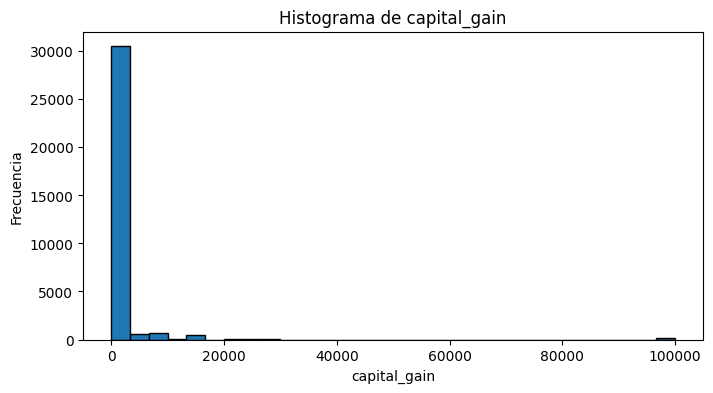

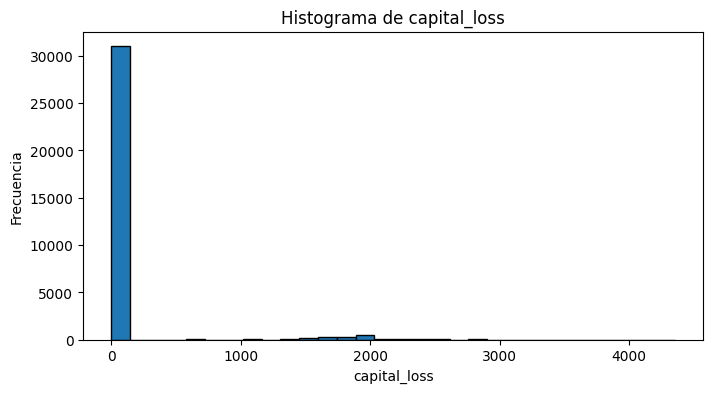

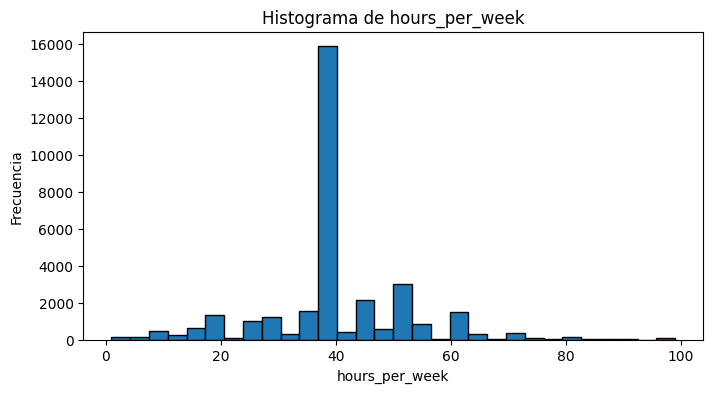

In [8]:
def Graficos(df):
    datos = df.select_dtypes(include=np.number)

    for variable in datos.columns:
        plt.figure(figsize=(8, 4))
        plt.hist(datos[variable], bins=30, edgecolor="black")
        plt.xlabel(variable)
        plt.ylabel("Frecuencia")
        plt.title(f"Histograma de {variable}")
        plt.show()

Graficos(df)

### Boxplots

In [ ]:
def Boxplots(df):
    datos = df.select_dtypes(include=np.number)

    for variable in datos.columns:
        plt.figure(figsize=(8, 2))
        sns.boxplot(x=datos[variable])
        plt.xlabel(variable)
        plt.title(f"Boxplot de {variable}")
        plt.show()

Boxplots(df)

## 9. Variable respuesta y desbalance

Frecuencias:
income
<=50K    24698
>50K      7839
Name: count, dtype: int64

Porcentajes:
income
<=50K    75.907428
>50K     24.092572
Name: proportion, dtype: float64


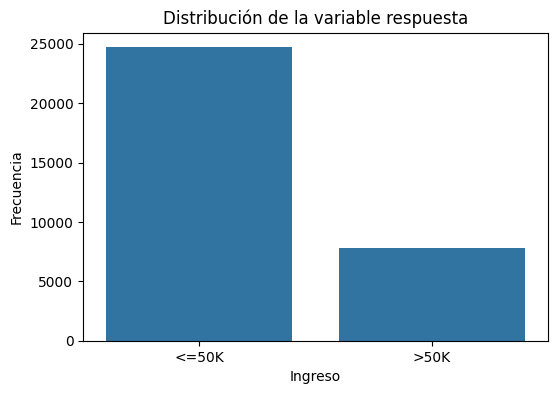

In [9]:
print("Frecuencias:")
print(df["income"].value_counts())

print("Porcentajes:")
print(df["income"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="income")
plt.xlabel("Ingreso")
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable respuesta")
plt.show()

Primero se evalúa el desbalance observado. No se aplica automáticamente una técnica de balanceo.

## 10. Separar X e y

In [10]:
X = df.drop(columns=["income"])
y = df["income"]

print("X:", X.shape)
print("y:", y.shape)

X: (32537, 14)
y: (32537,)


## 11. Dividir TRAIN y TEST

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("TRAIN:", X_train.shape)
print("TEST:", X_test.shape)

print("TRAIN:")
print(y_train.value_counts(normalize=True))

print("TEST:")
print(y_test.value_counts(normalize=True))

TRAIN: (22775, 14)
TEST: (9762, 14)
TRAIN:
income
<=50K    0.759078
>50K     0.240922
Name: proportion, dtype: float64
TEST:
income
<=50K    0.759066
>50K     0.240934
Name: proportion, dtype: float64


## 12. Imputación de datos faltantes

In [13]:
X_train_prep = X_train.copy()
X_test_prep = X_test.copy()

for variable in variables_cat:
    moda = X_train_prep[variable].mode()[0]
    X_train_prep[variable] = X_train_prep[variable].fillna(moda)
    X_test_prep[variable] = X_test_prep[variable].fillna(moda)

print("Faltantes TRAIN:", X_train_prep.isnull().sum().sum())
print("Faltantes TEST:", X_test_prep.isnull().sum().sum())

Faltantes TRAIN: 0
Faltantes TEST: 0


## 13. One-Hot Encoding

In [14]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_train_cat = encoder.fit_transform(X_train_prep[variables_cat])
X_test_cat = encoder.transform(X_test_prep[variables_cat])

columnas_encoded = encoder.get_feature_names_out(variables_cat)

X_train_cat = pd.DataFrame(X_train_cat, columns=columnas_encoded, index=X_train_prep.index)
X_test_cat = pd.DataFrame(X_test_cat, columns=columnas_encoded, index=X_test_prep.index)

## 14. Unir variables cuantitativas y categóricas

In [15]:
X_train_num = X_train_prep[variables_num]
X_test_num = X_test_prep[variables_num]

X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)

print("TRAIN final:", X_train_final.shape)
print("TEST final:", X_test_final.shape)

TRAIN final: (22775, 105)
TEST final: (9762, 105)


## 15. Árbol CART de clasificación

In [16]:
from sklearn.tree import DecisionTreeClassifier

modelo_CART = DecisionTreeClassifier(random_state=42)
modelo_CART.fit(X_train_final, y_train)

DecisionTreeClassifier(random_state=42)

## 16. Predicciones

In [17]:
predicciones = modelo_CART.predict(X_test_final)
predicciones[:20]

array(['<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '>50K', '<=50K',
       '<=50K', '<=50K', '>50K', '>50K', '<=50K', '<=50K', '<=50K',
       '>50K', '<=50K', '<=50K', '<=50K', '<=50K', '>50K'], dtype=object)

## 17. Matriz de confusión

[[6513  897]
 [ 857 1495]]


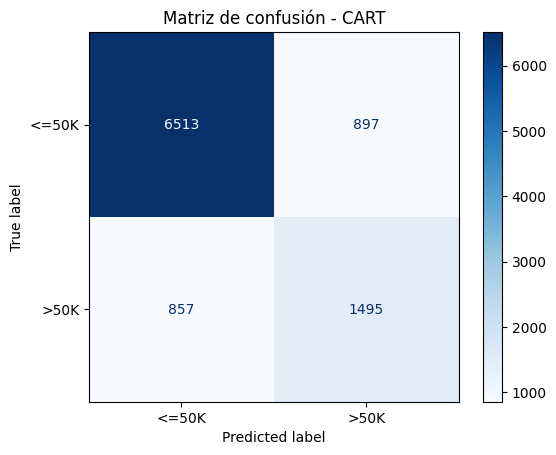

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

matriz_confusion = confusion_matrix(
    y_test, predicciones,
    labels=["<=50K", ">50K"]
)

print(matriz_confusion)

ConfusionMatrixDisplay.from_predictions(
    y_test, predicciones,
    labels=["<=50K", ">50K"],
    cmap="Blues"
)

plt.title("Matriz de confusión - CART")
plt.show()

Con el orden de clases anterior:

| | Predicho <=50K | Predicho >50K |
|---|---:|---:|
| Real <=50K | TN | FP |
| Real >50K | FN | TP |

## 18. Accuracy, Precision, Recall, Specificity y F1

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, predicciones)
precision = precision_score(y_test, predicciones, pos_label=">50K")
recall = recall_score(y_test, predicciones, pos_label=">50K")
f1 = f1_score(y_test, predicciones, pos_label=">50K")

TN, FP, FN, TP = matriz_confusion.ravel()
specificity = TN / (TN + FP)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)
print("F1-score:", f1)

Accuracy: 0.8203237041589838
Precision: 0.625
Recall: 0.6356292517006803
Specificity: 0.8789473684210526
F1-score: 0.6302698145025295


## 19. Classification report

In [20]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predicciones))

              precision    recall  f1-score   support

       <=50K       0.88      0.88      0.88      7410
        >50K       0.62      0.64      0.63      2352

    accuracy                           0.82      9762
   macro avg       0.75      0.76      0.76      9762
weighted avg       0.82      0.82      0.82      9762



## 20. ROC-AUC y curva ROC

ROC-AUC: 0.7572883100608664


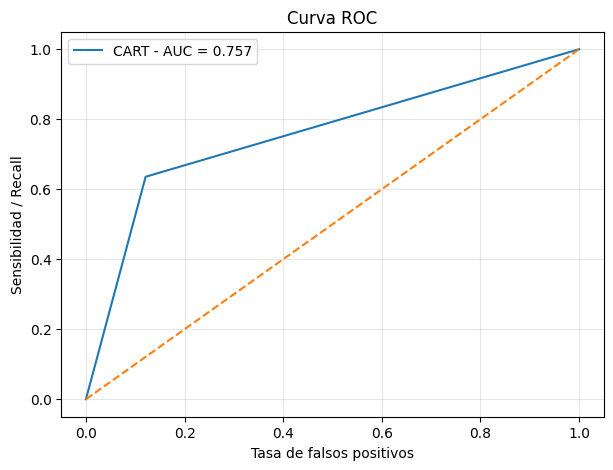

In [21]:
from sklearn.metrics import roc_auc_score, roc_curve

probabilidades = modelo_CART.predict_proba(X_test_final)
indice_positivo = list(modelo_CART.classes_).index(">50K")
prob_positiva = probabilidades[:, indice_positivo]

y_test_binario = (y_test == ">50K").astype(int)
auc = roc_auc_score(y_test_binario, prob_positiva)

print("ROC-AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_test_binario, prob_positiva)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"CART - AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Sensibilidad / Recall")
plt.title("Curva ROC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Interpretación de la curva ROC

La curva ROC se encuentra por encima de la línea diagonal, lo que indica que el modelo CART presenta una capacidad de discriminación superior a una clasificación aleatoria.

El modelo obtuvo un **AUC = 0.757**, lo que significa que presenta una capacidad de discriminación moderada entre las clases `<=50K` y `>50K`.

Sin embargo, todavía existe margen de mejora, ya que un modelo con mayor capacidad discriminativa tendría una curva más cercana a la esquina superior izquierda y un AUC más próximo a 1.

## 21. Revisar sobreajuste

In [22]:
pred_train = modelo_CART.predict(X_train_final)
pred_test = modelo_CART.predict(X_test_final)

accuracy_train = accuracy_score(y_train, pred_train)
accuracy_test = accuracy_score(y_test, pred_test)

f1_train = f1_score(y_train, pred_train, pos_label=">50K")
f1_test = f1_score(y_test, pred_test, pos_label=">50K")

print("Accuracy TRAIN:", accuracy_train)
print("Accuracy TEST:", accuracy_test)
print("F1 TRAIN:", f1_train)
print("F1 TEST:", f1_test)

Accuracy TRAIN: 1.0
Accuracy TEST: 0.8203237041589838
F1 TRAIN: 1.0
F1 TEST: 0.6302698145025295


## 22. Regularización con Grid Search

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

modelo_grid = DecisionTreeClassifier(random_state=42)

param_grid = {
    "max_depth": [3, 5, 7, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "criterion": ["gini", "entropy"]
}

f1_scorer = make_scorer(f1_score, pos_label=">50K")

grid = GridSearchCV(
    estimator=modelo_grid,
    param_grid=param_grid,
    cv=5,
    scoring=f1_scorer,
    n_jobs=-1
)

grid.fit(X_train_final, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, 15, 20],
                         'min_samples_leaf': [1, 2, 5, 10, 20],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring=make_scorer(f1_score, response_method='predict', pos_label=>50K))

## 23. Mejores hiperparámetros

In [24]:
print("Mejores hiperparámetros:")
print(grid.best_params_)

print("\nMejor F1 promedio en validación cruzada:")
print(grid.best_score_)

Mejores hiperparámetros:
{'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 20}

Mejor F1 promedio en validación cruzada:
0.6654079189214104


## 24. Evaluar CART regularizado

In [25]:
modelo_final = grid.best_estimator_
pred_final = modelo_final.predict(X_test_final)

accuracy_final = accuracy_score(y_test, pred_final)
precision_final = precision_score(y_test, pred_final, pos_label=">50K")
recall_final = recall_score(y_test, pred_final, pos_label=">50K")
f1_final = f1_score(y_test, pred_final, pos_label=">50K")

cm_final = confusion_matrix(y_test, pred_final, labels=["<=50K", ">50K"])
TN_f, FP_f, FN_f, TP_f = cm_final.ravel()
specificity_final = TN_f / (TN_f + FP_f)

print("Accuracy:", accuracy_final)
print("Precision:", precision_final)
print("Recall:", recall_final)
print("Specificity:", specificity_final)
print("F1:", f1_final)

Accuracy: 0.8585330874820734
Precision: 0.7586574320724561
Recall: 0.6054421768707483
Specificity: 0.9388663967611336
F1: 0.6734452589264601


## 25. Matriz de confusión del CART regularizado

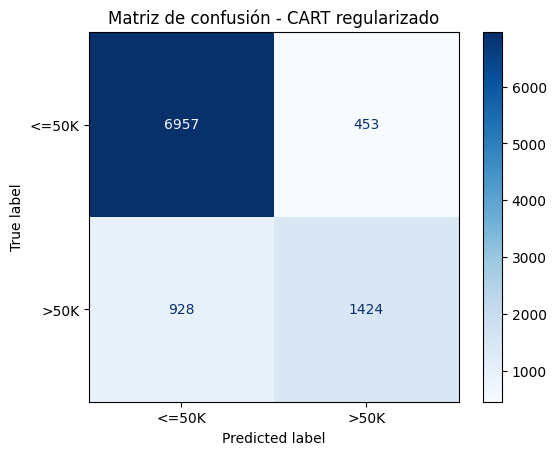

In [26]:
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_final,
    labels=["<=50K", ">50K"],
    cmap="Blues"
)

plt.title("Matriz de confusión - CART regularizado")
plt.show()

### Interpretación de la matriz de confusión

El CART regularizado clasificó correctamente **6,957 observaciones de la clase `<=50K`** y **1,424 observaciones de la clase `>50K`**.

El modelo presenta un mejor desempeño identificando la clase `<=50K`, con una **Specificity aproximada de 93.9%**. Para la clase `>50K`, el **Recall es aproximadamente 60.5%**, lo que indica que el modelo identifica cerca de 6 de cada 10 personas que realmente pertenecen a esta clase.

Además, se presentaron **453 falsos positivos** y **928 falsos negativos**. Por tanto, el principal punto de mejora del modelo se encuentra en la detección de personas de la clase `>50K`, ya que una proporción importante de estas observaciones todavía es clasificada como `<=50K`.

En conjunto, el modelo alcanza un **Accuracy aproximado de 85.9%**, aunque la matriz de confusión muestra la importancia de no evaluar su desempeño únicamente mediante esta métrica debido al desbalance entre las clases.

## 26. Comparar los dos modelos

In [27]:
comparacion = pd.DataFrame({
    "Modelo": ["CART original", "CART regularizado"],
    "Accuracy": [accuracy, accuracy_final],
    "Precision": [precision, precision_final],
    "Recall": [recall, recall_final],
    "Specificity": [specificity, specificity_final],
    "F1": [f1, f1_final]
})

comparacion

,Modelo,Accuracy,Precision,Recall,Specificity,F1
0,CART original,0.820324,0.625000,0.635629,0.878947,0.630270
1,CART regularizado,0.858533,0.758657,0.605442,0.938866,0.673445


## 27. Importancia de variables

In [28]:
importancias = pd.DataFrame({
    "Variable": X_train_final.columns,
    "Importancia": modelo_final.feature_importances_
}).sort_values("Importancia", ascending=False)

importancias.head(15)

,Variable,Importancia
32,marital_status_Married-civ-spouse,0.330935
3,capital_gain,0.167090
2,education_num,0.161902
0,age,0.089171
4,capital_loss,0.054299
1,fnlwgt,0.049974
5,hours_per_week,0.049915
40,occupation_Exec-managerial,0.009858
25,education_HS-grad,0.007298
11,workclass_Self-emp-not-inc,0.007173


### Gráfico de las variables más importantes

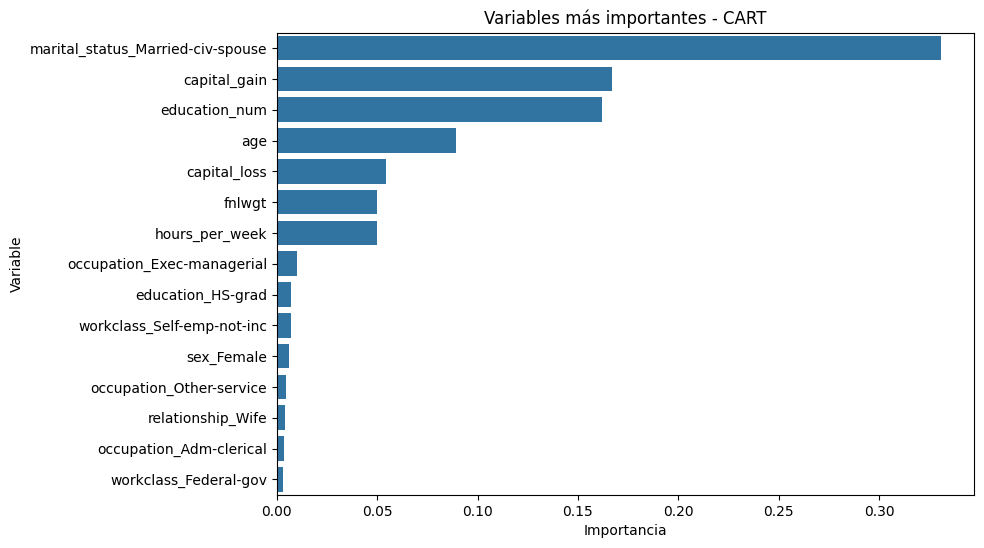

In [29]:
top15 = importancias.head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=top15, x="Importancia", y="Variable")
plt.title("Variables más importantes - CART")
plt.show()

## 28. Revisar una muestra de 10 predicciones

In [35]:
muestra = X_test_final.sample(n=10, random_state=42)
y_muestra = y_test.loc[muestra.index]
pred_muestra = modelo_final.predict(muestra)

for i in range(10):
    real = y_muestra.iloc[i]
    predicho = pred_muestra[i]

    print(f"Observación {i + 1}")
    print("Valor real:", real)
    print("Predicción:", predicho)

    if real == predicho:
        print("Clasificación correcta")
    else:
        print("Clasificación incorrecta")

    print("----")

Observación 1
Valor real: <=50K
Predicción: <=50K
Clasificación correcta
----
Observación 2
Valor real: <=50K
Predicción: <=50K
Clasificación correcta
----
Observación 3
Valor real: <=50K
Predicción: <=50K
Clasificación correcta
----
Observación 4
Valor real: <=50K
Predicción: <=50K
Clasificación correcta
----
Observación 5
Valor real: <=50K
Predicción: <=50K
Clasificación correcta
----
Observación 6
Valor real: <=50K
Predicción: <=50K
Clasificación correcta
----
Observación 7
Valor real: <=50K
Predicción: <=50K
Clasificación correcta
----
Observación 8
Valor real: <=50K
Predicción: <=50K
Clasificación correcta
----
Observación 9
Valor real: <=50K
Predicción: <=50K
Clasificación correcta
----
Observación 10
Valor real: <=50K
Predicción: <=50K
Clasificación correcta
----


## 29. Tabla de las 10 predicciones

In [31]:
revision = pd.DataFrame({
    "Real": y_muestra.values,
    "Predicción": pred_muestra
})

revision["Resultado"] = np.where(
    revision["Real"] == revision["Predicción"],
    "Correcta",
    "Incorrecta"
)

revision

,Real,Predicción,Resultado
0,<=50K,<=50K,Correcta
1,<=50K,<=50K,Correcta
2,<=50K,<=50K,Correcta
3,<=50K,<=50K,Correcta
4,<=50K,<=50K,Correcta
5,<=50K,<=50K,Correcta
6,<=50K,<=50K,Correcta
7,<=50K,<=50K,Correcta
8,<=50K,<=50K,Correcta
9,<=50K,<=50K,Correcta


## Conclusión

Se construyó un modelo **CART de clasificación** para predecir si el ingreso de una persona pertenece a la categoría `<=50K` o `>50K`.

El desempeño del modelo se evaluó mediante la **matriz de confusión**, Accuracy, Precision, Recall, Specificity, F1-score y ROC-AUC. El uso conjunto de estas métricas permite evaluar el modelo de manera más completa, especialmente porque las clases presentan diferentes frecuencias.

Posteriormente, se comparó el desempeño del modelo en **TRAIN y TEST** con el propósito de identificar posibles problemas de sobreajuste. Para controlar la complejidad del árbol se realizó una búsqueda de hiperparámetros mediante **GridSearchCV con validación cruzada**, utilizando el **F1-score de la clase `>50K`** como criterio de optimización.

Finalmente, se evaluó el **CART regularizado**, se analizaron las variables con mayor importancia dentro del árbol y se revisó una muestra de **10 observaciones**, comparando la clasificación real con la predicción realizada por el modelo.

Este ejercicio muestra que en un problema de clasificación no es suficiente evaluar únicamente el Accuracy. Es importante analizar conjuntamente los diferentes tipos de errores y métricas para determinar qué tan bien el modelo identifica cada una de las clases y qué tan bien generaliza ante datos no utilizados durante el entrenamiento.